<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Clase 19: Análisis de sesgo, varianza y equidad de un modelo**

### **1.Importación de datos**

Se utilizará el conjunto de datos [German Credit](https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk) cuyo objetivo es clasificar a los clientes según riesgo crediticio:

In [1]:
import kagglehub

path = kagglehub.dataset_download("kabure/german-credit-data-with-risk")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'german-credit-data-with-risk' dataset.
Path to dataset files: /kaggle/input/german-credit-data-with-risk


In [2]:
#se importa la librería
import pandas as pd

DATA=pd.read_csv("/kaggle/input/german-credit-data-with-risk/german_credit_data.csv", index_col=0)
DATA.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
DATA.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


### **2.Transformación**

In [4]:
datak=DATA.copy()

In [5]:
datak['Sex'].unique()

array(['male', 'female'], dtype=object)

In [6]:
datak['Saving accounts'].unique()

array([nan, 'little', 'quite rich', 'rich', 'moderate'], dtype=object)

In [7]:
datak['Checking account'].unique()

array(['little', 'moderate', nan, 'rich'], dtype=object)

In [8]:
datak['Housing'].unique()

array(['own', 'free', 'rent'], dtype=object)

In [9]:
datak['Purpose'].unique()

array(['radio/TV', 'education', 'furniture/equipment', 'car', 'business',
       'domestic appliances', 'repairs', 'vacation/others'], dtype=object)

In [10]:
datak['Risk'].unique()

array(['good', 'bad'], dtype=object)

In [11]:
datak.dtypes

,0
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object
Risk,object


In [12]:
datak.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [13]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

datak['Sex'] = le.fit_transform(datak['Sex'])
datak['Housing'] = le.fit_transform(datak['Housing'])
datak['Saving accounts'] = le.fit_transform(datak['Saving accounts'])
datak['Checking account'] = le.fit_transform(datak['Checking account'])
datak['Purpose'] = le.fit_transform(datak['Purpose'])

datak['Risk'] =le.fit_transform(datak['Risk'])

In [14]:
datak

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,1736,12,4,1
996,40,1,3,1,0,0,3857,30,1,1
997,38,1,2,1,0,3,804,12,5,1
998,23,1,2,0,0,0,1845,45,5,0


In [15]:
datak.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


Luego debería hacer un análisis exploratorio

### **3.Preparación de datos**

In [16]:
X=datak.drop('Risk', axis = 1)
y=datak['Risk']

In [17]:
# Aplicamos SMOTE para equilibrar la clase objetivo
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X, y)

RISK: 0:bad, 1: good

Se debe particionar el conjunto de datos en dos: una parte para entrenar el modelo y otra aprte para testear el mismo.

In [18]:
# se importa la librería
import numpy as np
from sklearn.model_selection import train_test_split

In [19]:
#seteo de semilla
np.random.seed(42)
#generamos para cada uno de los anteriores, conjuntos de datos de entrenamiento(80%) y testeo(20%)
X_train, X_test, y_train, y_test= train_test_split(x_resampled, y_resampled, train_size= 0.8)


In [20]:
#se observan dimensiones
X_train.shape, X_test.shape

((1120, 9), (280, 9))

In [21]:
#se observan dimensiones
y_train.shape, y_test.shape

((1120,), (280,))

### **4. Aplicación de Decision Tree y XGBoost**

In [22]:
import sklearn
from sklearn.tree import DecisionTreeClassifier

#Árbol de decisión
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
ypred_test_tree = tree.predict(X_test)

In [23]:
#Medidas de performance
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test_tree))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71       131
           1       0.75      0.71      0.73       149

    accuracy                           0.72       280
   macro avg       0.72      0.72      0.72       280
weighted avg       0.72      0.72      0.72       280



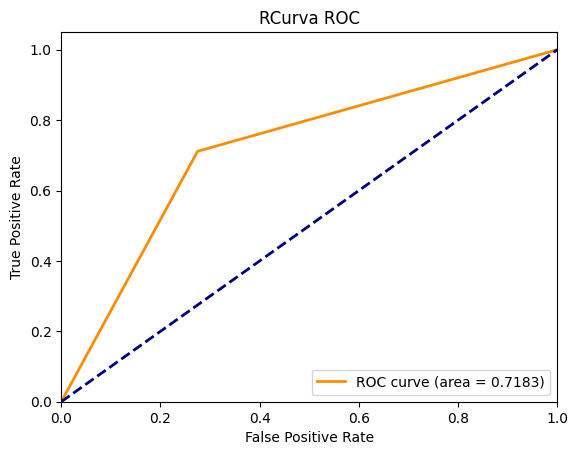

In [24]:
#Obtención de AUC y Curva ROC
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

y_pred_tree = tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_tree)
AUC = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(fpr,tpr,color="darkorange",lw=lw,label="ROC curve (area = %0.4f)" % AUC,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RCurva ROC")
plt.legend(loc="lower right")
plt.show()

In [25]:
#Aplicación
import sklearn
import xgboost as xgb

xgb_1 = xgb.XGBClassifier(objective='binary:logistic') # utilizando parámetros por default
xgb_1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [26]:
ypred_test_xgb = xgb_1.predict(X_test)

In [27]:
#Medidas de performance
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test_xgb))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       131
           1       0.84      0.76      0.80       149

    accuracy                           0.80       280
   macro avg       0.80      0.80      0.80       280
weighted avg       0.80      0.80      0.80       280



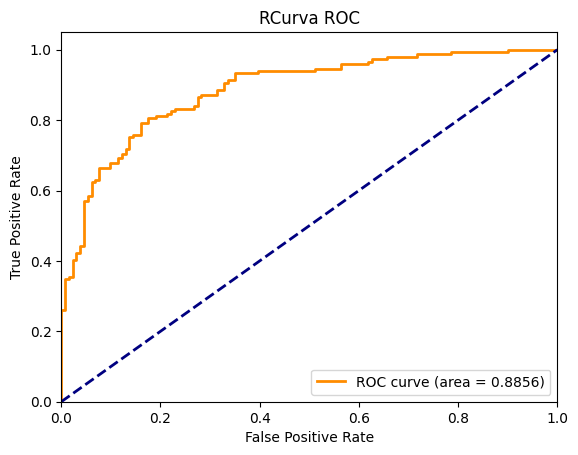

In [28]:
#Obtención de AUC y Curva ROC
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

y_pred_xgb = xgb_1.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)
AUC = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(fpr,tpr,color="darkorange",lw=lw,label="ROC curve (area = %0.4f)" % AUC,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RCurva ROC")
plt.legend(loc="lower right")
plt.show()

### **5.Análisis de sesgo y varianza**

Cálculo de Bias y Variance

In [29]:
!pip install mlxtend

In [30]:
from mlxtend.evaluate import bias_variance_decomp

In [31]:
#Para el árbol de decisión
avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(tree, X_train.values, y_train.ravel(), X_test.values, y_test.ravel(),
                                                            loss='0-1_loss',
                                                            random_seed=42)

print('Average expected loss: %.3f' % avg_expected_loss)
print('Average bias: %.3f' % avg_bias)
print('Average variance: %.3f' % avg_var)

/tmp/ipykernel_88780/1949966110.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(tree, X_train.values, y_train.ravel(), X_test.values, y_test.ravel(),


Average expected loss: 0.294
Average bias: 0.218
Average variance: 0.205


In [32]:
#Para XGBoost
avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(xgb_1, X_train.values, y_train.ravel(), X_test.values, y_test.ravel(),
                                                            loss='0-1_loss',
                                                            random_seed=42)

print('Average expected loss: %.3f' % avg_expected_loss)
print('Average bias: %.3f' % avg_bias)
print('Average variance: %.3f' % avg_var)

/tmp/ipykernel_88780/2379943038.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(xgb_1, X_train.values, y_train.ravel(), X_test.values, y_test.ravel(),


Average expected loss: 0.221
Average bias: 0.186
Average variance: 0.100


Al comparar el Bias y Variance del árbol de decisión y XGBoost, es posible observar que XGBoost logra reducir la varianza y el Bias

### **6. Análisis de equidad**

https://dalex.drwhy.ai/

In [33]:
!pip install dalex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 80.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [34]:
import dalex as dx

In [35]:
exp = dx.Explainer(xgb_1, X_test, y_test, verbose=False)

In [36]:
# definición de variable sensible
protected = np.where(X_test.Sex == 0, 'Female', 'Male')

privileged = 'Male'

In [37]:
fobject = exp.model_fairness(protected = protected, privileged=privileged)

In [38]:
fobject.fairness_check(epsilon = 0.8)

Bias detected in 3 metrics: TPR, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Male'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
             TPR       ACC       PPV   FPR       STP
Female  0.732412  0.943609  0.809249  0.74  0.544014


In [50]:
fobject.plot()

/usr/local/lib/python3.12/dist-packages/dalex/fairness/_group_fairness/utils.py:209: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(dropna=False)


Si las barras se encuentran en la zona verde (más cercanas a 1), hay equidad

El posible observar en tres medidas que el modelo esta siendo injusto o inequitativo para los clientes según género

#### **Corrección de la Inequidad**

In [40]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,1,2,1,4,0,1169,6,5
1,22,0,2,1,0,1,5951,48,5
2,49,1,1,1,0,3,2096,12,3
3,45,1,2,0,0,0,7882,42,4
4,53,1,2,0,0,0,4870,24,1
...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,1736,12,4
996,40,1,3,1,0,0,3857,30,1
997,38,1,2,1,0,3,804,12,5
998,23,1,2,0,0,0,1845,45,5


In [41]:
#balanceamos también por género
from imblearn.over_sampling import SMOTENC
smote_nc = SMOTENC(categorical_features=[1], random_state=42)
X_resampled1, y_resampled1 = smote_nc.fit_resample(X, y)

In [42]:
from sklearn.model_selection import train_test_split

X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X_resampled1, y_resampled1, test_size=0.2, random_state=42)

In [44]:
#aplicamos  nuevamnente XGBoost

In [43]:
#Aplicación
import sklearn
import xgboost as xgb

xgb_1_1= xgb.XGBClassifier(objective='binary:logistic') # utilizando parámetros por default
xgb_1_1.fit(X_train1, Y_train1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [45]:
ypred_test_xgb_1 = xgb_1_1.predict(X_test1)

In [46]:
#Medidas de performance
from sklearn.metrics import classification_report
print(classification_report(Y_test1, ypred_test_xgb_1))

              precision    recall  f1-score   support

           0       0.75      0.82      0.79       131
           1       0.83      0.76      0.79       149

    accuracy                           0.79       280
   macro avg       0.79      0.79      0.79       280
weighted avg       0.79      0.79      0.79       280



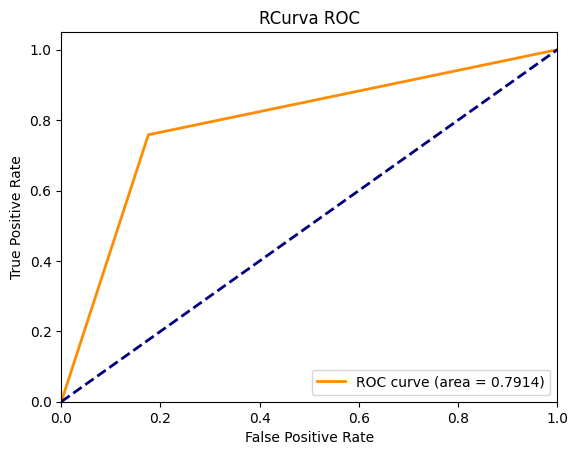

In [47]:
#Obtención de AUC y Curva ROC
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

y_pred_xgb = xgb_1.predict_proba(X_test1)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test1, ypred_test_xgb_1)
AUC = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(fpr,tpr,color="darkorange",lw=lw,label="ROC curve (area = %0.4f)" % AUC,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RCurva ROC")
plt.legend(loc="lower right")
plt.show()

**Realizamos nuevamente el Análisis de equidad**

In [48]:
# definición de variable sensible
protected = np.where(X_test1.Sex == 0, 'Female', 'Male')

privileged = 'Male'

In [49]:
exp_opt  = dx.Explainer(xgb_1_1, X_test1, Y_test1, verbose = False, model_type='classification')

fobject_opt = exp_opt.model_fairness(protected, privileged)

fobject_opt.fairness_check(epsilon = 0.8)

fobject_opt.plot()

Bias detected in 1 metric: FPR

Conclusion: your model cannot be called fair because 1 criterion exceeded acceptable limits set by epsilon.
It does not mean that your model is unfair but it cannot be automatically approved based on these metrics.

Ratios of metrics, based on 'Male'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
             TPR       ACC       PPV       FPR       STP
Female  0.846447  0.883149  0.876168  1.467949  0.905622


/usr/local/lib/python3.12/dist-packages/dalex/fairness/_group_fairness/utils.py:209: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(dropna=False)


Ahora observamos que hay equidad, ya que no hay al menso 2 o 3 medidas que estén en zona roja